In [2]:
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import scanpy as sc
import os
main_path = os.getcwd()

from skbio.stats.composition import clr, multiplicative_replacement

In [3]:
def generate_frequency_vector(complete_df, matching_field, groupby, leiden_clusters, transform=True, meta_field=None, min_tiles=1, min_perc=0):
    if min_perc >= 1:
        raise ValueError('Minimum percentage should be in the range 0-1')
    
    lr_data = list()
    lr_label = list()
    lr_samples = list()

    for sample in pd.unique(complete_df[matching_field].unique()):
        samples_df = complete_df[complete_df[matching_field] == sample]
        samples_df = samples_df[samples_df[groupby].isin(leiden_clusters)]

        num_tiles = samples_df.shape[0]
        if num_tiles < min_tiles:
            print(f'Sample: {sample} - {num_tiles} tiles. Skipping')
            continue
        
        # samples_features = [0]*len(leiden_clusters)
        samples_features = dict()
        for clust_id in leiden_clusters:
            samples_features[clust_id] = 0

        clusters_slide, clusters_counts = np.unique(samples_df[groupby], return_counts=True)
        for clust_id, count in zip(clusters_slide, clusters_counts):
            # samples_features[int(clust_id)] = count

            if (count / num_tiles) > min_perc:
                samples_features[clust_id] = count
            else:
                samples_features[clust_id] = 0

        # samples_features = np.array(samples_features, dtype=np.float64)
        samples_features = np.fromiter(samples_features.values(), dtype=np.float64)
        samples_features = np.array(samples_features) / np.sum(samples_features)
        if transform:
            samples_features = multiplicative_replacement(np.reshape(samples_features, (1,-1)))
            samples_features = clr(np.reshape(samples_features, (1,-1)))

        lr_samples.append(sample)
        lr_data.append(samples_features)

        try:
            samples_label = samples_df[meta_field].values[0]
            lr_label.append(samples_label)
        except:
            continue
            
    sample_rep_df = pd.DataFrame(data=lr_data, columns=leiden_clusters)
    sample_rep_df[matching_field] = lr_samples

    if len(lr_label) > 0:
        sample_rep_df[meta_field] = lr_label
        lr_label = np.stack(lr_label)
        lr_data = np.stack(lr_data)
    
        return lr_data, lr_label, sample_rep_df

    else:
        return sample_rep_df

In [4]:
ssl_adata_train = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-train.hdf5'))
ssl_adata_valid = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-valid.hdf5'))

In [5]:
leiden_clusters = np.unique(ssl_adata_train.obs['leiden'].unique())
ssl_adata_train.obs['samples'] = ssl_adata_train.obs['samples'].astype(float)
ssl_adata_valid.obs['samples'] = ssl_adata_valid.obs['samples'].astype(float)

In [6]:
train_df = generate_frequency_vector(complete_df=ssl_adata_train.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=False)
valid_df =  generate_frequency_vector(complete_df=ssl_adata_valid.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=False)

In [7]:
all_df = pd.concat([train_df, valid_df])

### Hallmarks

In [8]:
hallmarks = pd.read_csv(os.path.join(main_path, 'data/results/GRI_CRC_ssGSEA_Hallmarks.csv'))
hallmarks = hallmarks.rename(columns={'Unnamed: 0':'pathway'}).set_index('pathway')
hallmarks.columns = [int(col.split('_')[1][2:]) for col in hallmarks.columns]
hallmarks

,197660,197661,197663,197664,197665,197669,197670,197672,197674,197675,...,177325,177049,177064,177086,177186,177188,177308,177309,177315,177330
pathway,,,,,,,,,,,,,,,,,,,,,
HALLMARK_ADIPOGENESIS,0.389393,0.399107,0.383142,0.349333,0.352596,0.313349,0.373239,0.316202,0.335066,0.402300,...,0.359239,0.391761,0.320231,0.418598,0.382538,0.387618,0.374911,0.336002,0.388271,0.374805
HALLMARK_ALLOGRAFT_REJECTION,0.134833,0.116493,0.073814,0.193638,0.181990,0.070646,0.194841,0.079867,0.070151,0.124692,...,0.146024,0.215818,0.145663,0.124185,0.107834,0.130147,0.222206,0.129727,0.166585,0.171400
HALLMARK_ANDROGEN_RESPONSE,0.430809,0.425183,0.512424,0.378779,0.453453,0.485782,0.388519,0.404067,0.414611,0.467234,...,0.374651,0.486264,0.402024,0.477530,0.424596,0.416632,0.433028,0.337134,0.454345,0.461507
HALLMARK_ANGIOGENESIS,0.183583,0.280883,0.106467,0.175574,0.179406,0.217397,0.328218,0.217248,0.199898,0.149524,...,0.159265,0.303762,0.131753,0.191236,0.208527,0.269877,0.232589,0.119920,0.345444,0.223830
HALLMARK_APICAL_JUNCTION,0.242513,0.263511,0.238727,0.252864,0.218092,0.265975,0.238842,0.297879,0.284433,0.244417,...,0.230999,0.307969,0.213536,0.284212,0.227264,0.299800,0.280016,0.224825,0.297865,0.250915
HALLMARK_APICAL_SURFACE,0.162244,0.174312,0.181798,0.166668,0.152726,0.115666,0.011409,0.141715,0.210304,0.230580,...,0.132389,0.187837,0.144793,0.101179,0.173315,0.135744,0.156900,0.092898,0.148624,0.141062
HALLMARK_APOPTOSIS,0.372843,0.382748,0.368888,0.372445,0.396037,0.351287,0.398640,0.382278,0.356734,0.365052,...,0.388463,0.429623,0.353207,0.404785,0.374403,0.420658,0.422277,0.380791,0.439032,0.406543
HALLMARK_BILE_ACID_METABOLISM,0.123757,0.076023,0.084919,0.153899,0.095013,0.081350,0.107458,0.067696,0.155905,0.147767,...,0.126109,0.105384,0.116912,0.115103,0.062097,0.100365,0.105580,0.138384,0.154850,0.126497
HALLMARK_CHOLESTEROL_HOMEOSTASIS,0.369043,0.431890,0.523903,0.371050,0.400910,0.396272,0.449032,0.424784,0.456274,0.455757,...,0.435276,0.422814,0.317069,0.389913,0.463169,0.443083,0.401367,0.391050,0.407885,0.399774


In [9]:
hallmarks_t = hallmarks.T.reset_index(names='samples')
hallmarks_t

pathway,samples,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,197660,0.389393,0.134833,0.430809,0.183583,0.242513,0.162244,0.372843,0.123757,0.369043,...,0.463283,0.471200,-0.122820,0.460852,0.328285,0.532454,0.351970,0.286654,0.364338,0.249590
1,197661,0.399107,0.116493,0.425183,0.280883,0.263511,0.174312,0.382748,0.076023,0.431890,...,0.516655,0.426212,-0.094660,0.449085,0.321551,0.558961,0.375728,0.334798,0.412551,0.248303
2,197663,0.383142,0.073814,0.512424,0.106467,0.238727,0.181798,0.368888,0.084919,0.523903,...,0.499358,0.453039,-0.021759,0.454209,0.325448,0.594042,0.384891,0.333682,0.265867,0.235106
3,197664,0.349333,0.193638,0.378779,0.175574,0.252864,0.166668,0.372445,0.153899,0.371050,...,0.359337,0.400267,-0.107793,0.412949,0.363685,0.483087,0.285375,0.324908,0.253511,0.205061
4,197665,0.352596,0.181990,0.453453,0.179406,0.218092,0.152726,0.396037,0.095013,0.400910,...,0.459046,0.459613,-0.078600,0.408925,0.423219,0.556447,0.340483,0.341199,0.242100,0.259005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,177188,0.387618,0.130147,0.416632,0.269877,0.299800,0.135744,0.420658,0.100365,0.443083,...,0.390433,0.447994,-0.149101,0.422117,0.452387,0.533178,0.341497,0.354482,0.254272,0.243782
314,177308,0.374911,0.222206,0.433028,0.232589,0.280016,0.156900,0.422277,0.105580,0.401367,...,0.421569,0.411024,-0.142297,0.494906,0.452052,0.507356,0.382791,0.303343,0.256168,0.261074
315,177309,0.336002,0.129727,0.337134,0.119920,0.224825,0.092898,0.380791,0.138384,0.391050,...,0.351965,0.351309,-0.130099,0.458418,0.349921,0.464586,0.338457,0.294221,0.295274,0.227181
316,177315,0.388271,0.166585,0.454345,0.345444,0.297865,0.148624,0.439032,0.154850,0.407885,...,0.461547,0.442823,-0.125207,0.501328,0.386782,0.529885,0.407155,0.311083,0.359098,0.252187


In [10]:
# hallmarks_corr = hallmarks_t.merge(train_df, on='samples').drop(labels='samples', axis=1).corr(method='spearman')
# hallmarks_corr = hallmarks_corr.loc[hallmarks_corr.index.str.contains('HALLMARK_'), [col for col in hallmarks_corr.columns if 'HALLMARK_' not in col]]
# hallmarks_corr

In [11]:
hallmarks_corr = pg.pairwise_corr(hallmarks_t.merge(all_df, on='samples').drop(labels='samples', axis=1),
                                  method='spearman', 
                                  padjust='fdr_bh')

hallmarks_corr

,X,Y,method,alternative,n,r,CI95%,p-unc,p-corr,p-adjust,power
0,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,spearman,two-sided,228,0.079345,"[-0.05, 0.21]",2.327217e-01,3.327549e-01,fdr_bh,0.222857
1,HALLMARK_ADIPOGENESIS,HALLMARK_ANDROGEN_RESPONSE,spearman,two-sided,228,0.665122,"[0.59, 0.73]",1.716691e-30,3.426287e-29,fdr_bh,1.000000
2,HALLMARK_ADIPOGENESIS,HALLMARK_ANGIOGENESIS,spearman,two-sided,228,0.231044,"[0.1, 0.35]",4.360858e-04,1.093611e-03,fdr_bh,0.942539
3,HALLMARK_ADIPOGENESIS,HALLMARK_APICAL_JUNCTION,spearman,two-sided,228,0.481964,"[0.38, 0.58]",1.155100e-14,7.226859e-14,fdr_bh,1.000000
4,HALLMARK_ADIPOGENESIS,HALLMARK_APICAL_SURFACE,spearman,two-sided,228,0.409629,"[0.3, 0.51]",1.227463e-10,5.314853e-10,fdr_bh,0.999998
...,...,...,...,...,...,...,...,...,...,...,...
2410,6,8,spearman,two-sided,228,0.471407,"[0.36, 0.57]",5.141946e-14,3.006731e-13,fdr_bh,1.000000
2411,6,9,spearman,two-sided,228,-0.196777,"[-0.32, -0.07]",2.843444e-03,6.521290e-03,fdr_bh,0.850041
2412,7,8,spearman,two-sided,228,-0.070425,"[-0.2, 0.06]",2.896615e-01,3.997329e-01,fdr_bh,0.185290
2413,7,9,spearman,two-sided,228,-0.275178,"[-0.39, -0.15]",2.509961e-05,7.097842e-05,fdr_bh,0.988855


In [13]:
hallmarks_corr.to_csv(os.path.join(main_path, 'data/results/GRI_CRC_ssGSEA_Hallmarks_corr.csv'))

In [14]:
hallmarks_corr_r = hallmarks_corr.pivot(index='X', columns='Y', values='r') #.combine_first(lambda x: x.T).fillna(1)
hallmarks_corr_r = hallmarks_corr_r.loc[hallmarks_corr_r.index.str.contains('HALLMARK_'), [col for col in hallmarks_corr_r.columns if 'HALLMARK_' not in col]]

hallmarks_corr_p = hallmarks_corr.pivot(index='X', columns='Y', values='p-corr')
hallmarks_corr_p = hallmarks_corr_p.loc[hallmarks_corr_p.index.str.contains('HALLMARK_'), [col for col in hallmarks_corr_p.columns if 'HALLMARK_' not in col]]

hallmarks_corr_r = hallmarks_corr_r[hallmarks_corr_p[hallmarks_corr_p <= 0.05].any(axis=1)]
hallmarks_corr_p = hallmarks_corr_p[hallmarks_corr_p[hallmarks_corr_p <= 0.05].any(axis=1)]
hallmarks_corr_p = hallmarks_corr_p.mask(hallmarks_corr_p < 0.05, '*')
hallmarks_corr_p = hallmarks_corr_p.mask(hallmarks_corr_p != '*', '')

In [15]:
hallmarks_corr_r.index = [x.replace("HALLMARK_", "") for x in hallmarks_corr_r.index]

Text(1278.625, 0.5, 'Pathway')

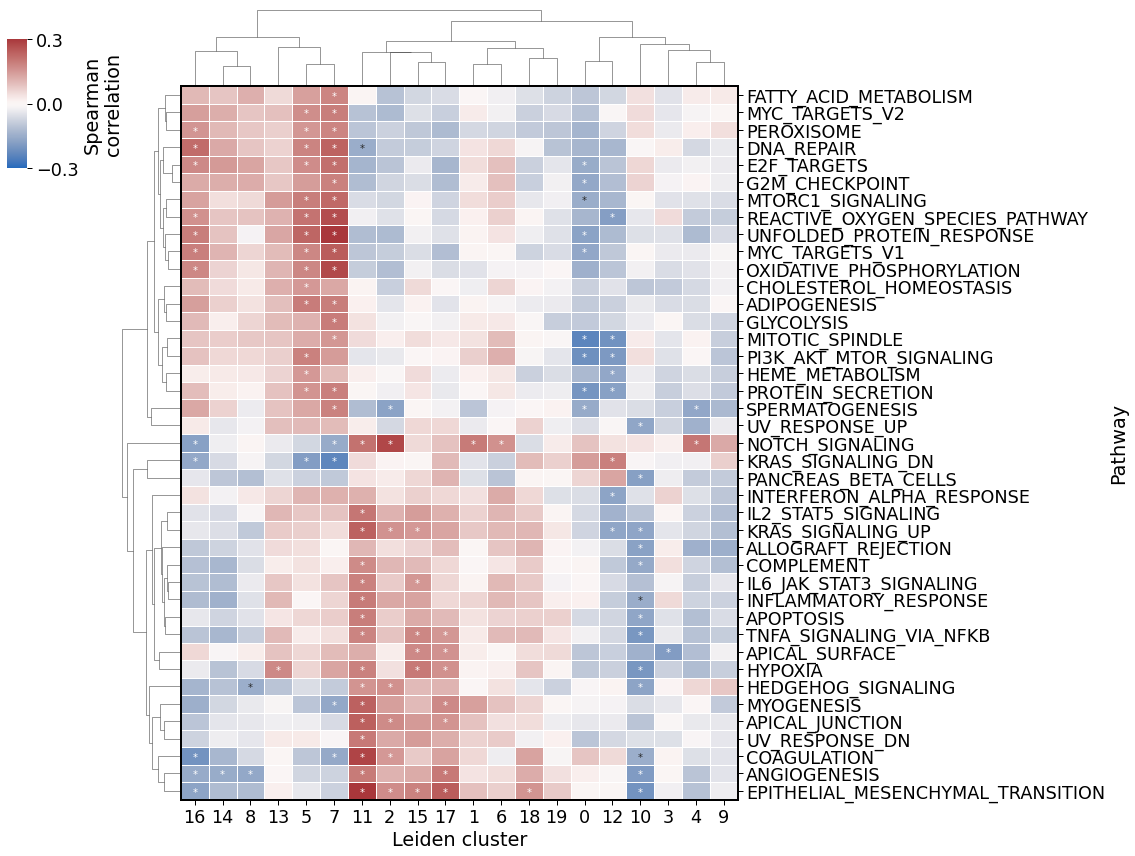

In [16]:
sns.set_context("paper", font_scale=2.0)

g = sns.clustermap(hallmarks_corr_r,
               annot=hallmarks_corr_p,
               fmt='',
               annot_kws={'va':'center_baseline', 'ha':'center', 'linespacing':0},
               cmap='vlag',
               vmin=-0.3, vmax=0.3,
               linewidths=.5,
               dendrogram_ratio=(.1,.1),
               cbar_pos=(-.1, .8, .02, .15),
               cbar_kws={'label':'Spearman\ncorrelation', 'ticks':[-0.3, 0.0, 0.3]},
               yticklabels=1,
               figsize=(14,12))

nrows, ncols = hallmarks_corr_r.shape
rect = Rectangle(
    xy=(0,0),
    width=ncols,
    height=nrows,
    fill=False,
    edgecolor='black',
    linewidth=2,
    clip_on=False
)

g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_xlabel('Leiden cluster')
g.ax_heatmap.set_ylabel('Pathway')